# LangGraph V1.0 Quickstart

이 튜토리얼은 간단한 설정부터 완전히 작동하는 AI 에이전트까지 단계별로 안내합니다.

환경 변수를 설정해야 원활하게 동작합니다.
이를 설정하기 위해서는 `.env` 에 키를 추가해야 합니다.

In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
from langchain_teddynote import logging

logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


## 모델 이름 지정

모델 이름을 지정할 때 다음 형식을 사용할 수 있습니다:

### 기본 형식

단순히 모델 이름만 지정:
* `'o3-mini'`
* `'claude-sonnet-4-5'`

### 통합 형식

모델 제공자와 모델을 함께 지정할 수 있습니다:

```
'{model_provider}:{model}'
```

**예시:**
* `'openai:o1'`
* `'anthropic:claude-sonnet-4-5'`

이 형식을 사용하면 하나의 인자로 모델 제공자와 모델을 동시에 명시할 수 있습니다.

**주요 파라미터**

* **temperature**: 출력의 무작위성을 조절하는 모델 온도 값
* **max_tokens**: 생성할 최대 토큰 수
* **timeout**: 응답 대기 최대 시간 (초 단위)
* **max_retries**: 요청 실패 시 최대 재시도 횟수
* **base_url**: 커스텀 API endpoint URL
* **rate_limiter**: 요청 속도를 제어하는 BaseRateLimiter 인스턴스

### 사용 예시

```python
model_kwargs = {
    "temperature": 0.7,
    "max_tokens": 1000,
    "timeout": 30
}
```

> **참고**: 사용 가능한 전체 파라미터 목록은 각 모델 제공자의 integration reference를 참조하세요.

- [공식문서](https://reference.langchain.com/python/langchain/models/?_gl=1*kundig*_gcl_au*MjAwMTM0Mzc1Mi4xNzYxNDEwNDky*_ga*MTI0ODcwNDIuMTc2MTgwNjA5Mg..*_ga_47WX3HKKY2*czE3NjE4MDYwNzUkbzUkZzEkdDE3NjE4MDYxMjEkajE0JGwwJGgw#langchain.chat_models.init_chat_model)

In [3]:
from langchain.chat_models import init_chat_model

# model 인스턴스 생성
llm = init_chat_model("openai:gpt-4.1", temperature=0)

In [4]:
from langchain_teddynote.messages import stream_response

result = llm.stream("반가워")
# 스트리밍 출력
stream_response(result)

반가워! 어떻게 도와줄까? 😊

## 에이전트 생성

LangGraph 기반의 에이전트를 사용합니다. 과거 `create_react_agent` 대신 `create_agent` 를 사용합니다.

In [5]:
from langchain.agents import create_agent

# 모델 식별자 문자열을 사용한 간단한 방법
agent = create_agent("openai:gpt-4.1-mini", tools=[])

만들어진 그래프 시각화

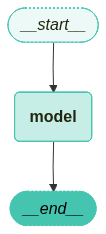

In [6]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(agent)

메시지 출력

In [7]:
from langchain_teddynote.messages import stream_graph
from langchain_core.messages import HumanMessage

stream_graph(agent, inputs={"messages": [HumanMessage(content="안녕하세요?")]})


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 어떻게 도와드릴까요?

## 기본 에이전트 구축

질문에 답하고 도구를 호출할 수 있는 간단한 에이전트를 만듭니다. 

기본 날씨 함수(실제로 기능이 있는 도구는 아닙니다!) 를 도구로 사용하며, 간단한 프롬프트로 동작을 안내합니다.

### 도구(Tool)

도구를 사용하면 모델이 정의한 함수를 호출하여 외부 시스템과 상호작용할 수 있습니다.

LangChain 에서는 `@tool` 데코레이터를 사용하여 도구를 정의합니다.

In [8]:
from langchain.tools import tool


# 날씨 정보를 반환하는 간단한 함수
@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

다음으로는 생성한 도구를 에이전트에 추가합니다.

In [9]:
from langchain.agents import create_agent

# 에이전트 생성
agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

In [10]:
agent.invoke({"city":"서울"})

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 46, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_7abc656409', 'id': 'chatcmpl-CklZBNcaIZVbGNMmJ9sQAHiMtd8J7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--59af7ab5-b791-409b-9ece-fff686622481-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_W2A9weTqsMnCBjIM5fWhCFKY', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Los Angeles'}, 'id': 'call_IjjAvsY8cjTUG1lZCPbKYjZK', 'type': 'tool_call'}], usage_metadata={'input_tokens': 46, 'output_tokens': 46, 'total_tokens': 92, 'input_toke

그래프 시각화를 수행합니다. 아래 그림은 `ReAct` 에이전트의 그래프 시각화입니다.



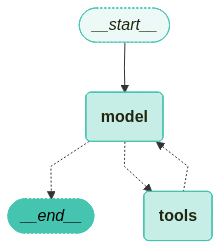

In [11]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(agent)

스트리밍 답변 출력을 진행합니다.

tool 호출을 결정할때는 항상 model은 비어져있다

In [12]:
# 에이전트 실행
stream_graph(agent, inputs={"messages": [HumanMessage(content="서울 날씨가 어때?")]})


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
It's always sunny in 서울!
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
서울은 현재 맑은 날씨입니다. 더 궁금한 점이나 다른 지역의 날씨가 필요하시면 말씀해 주세요!

## 컨택스트(Context)

### ToolRuntime

Tool 함수에 자동으로 주입되는 runtime context를 제공하는 dataclass입니다.

### 주요 속성

* `state`: 현재 graph state
* `tool_call_id`: 현재 tool call의 ID
* `config`: 현재 실행의 `RunnableConfig`
* `context`: Runtime context (langgraph `Runtime`에서 제공)
* `store`: 영구 저장소를 위한 `BaseStore` instance (langgraph `Runtime`에서 제공)
* `stream_writer`: 출력 streaming을 위한 `StreamWriter` (langgraph `Runtime`에서 제공)

### 사용 방법

`Annotated` wrapper 없이 `runtime: ToolRuntime`을 parameter로 선언하면 됩니다.

```python
from langchain_core.tools import tool
from langchain.tools import ToolRuntime

@tool
def my_tool(x: int, runtime: ToolRuntime) -> str:
    """Tool that accesses runtime context."""
    # state 접근
    messages = runtime.state["messages"]
    
    # tool_call_id 접근
    print(f"Tool call ID: {runtime.tool_call_id}")
    
    # config 접근
    print(f"Run ID: {runtime.config.get('run_id')}")
    
    # runtime context 접근
    user_id = runtime.context.get("user_id")
    
    # store 접근
    runtime.store.put(("metrics",), "count", 1)
    
    # 출력 streaming
    runtime.stream_writer.write("Processing...")
    
    return f"Processed {x}"
```

컨택스트는 도구에 전달되는 추가 정보를 제공합니다. 

`runtime.context` 를 통해 컨택스트에 접근할 수 있습니다.

```python
runtime.context.user_id
```

In [12]:
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


USER_DATABASE = {
    "teddy": {
        "name": "Teddy Lee",
        "account_type": "Premium",
        "balance": 5000,
        "email": "teddy@example.com",
    },
    "shirley": {
        "name": "Shirley Kim",
        "account_type": "Standard",
        "balance": 1200,
        "email": "shirley@example.com",
    },
}

Tool 함수의 parameter에 `tool_runtime`이라는 이름과 `ToolRuntime` type hint를 사용하면, tool 실행 시스템이 자동으로 runtime 정보를 포함한 instance를 주입합니다.

In [ ]:
# 사용자 컨택스트 정의
@dataclass
class UserContext:
    user_id: str


@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""

    # 사용자 컨택스트에 접근하여 `user_id` 를 가져옵니다. 
    # runtime.context: Agent를 호출할 때 context라는 파라미터에다 무언가 값을 담아서 보내겠다.
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"

In [14]:
agent = create_agent(
    # 에이전트 생성
    model="openai:gpt-4.1-mini",
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant.",
)

In [15]:
from langchain_teddynote.messages import stream_graph
from langchain_core.messages import HumanMessage

stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="내 계좌의 현재 잔고를 알려주세요.")]},
    context=UserContext(user_id="teddy"),
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Account holder: Teddy Lee
Type: Premium
Balance: $5000
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 귀하의 계좌 잔고는 $5000입니다. 추가로 궁금한 점이 있으신가요?

In [16]:
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="내 계좌의 현재 잔고를 알려주세요.")]},
    context=UserContext(user_id="shirley"),
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Account holder: Shirley Kim
Type: Standard
Balance: $1200
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 계좌의 잔고는 1,200 달러입니다. 다른 도움이 필요하시면 말씀해 주세요.

## 응답 형식(Response Format)

에이전트 응답이 특정 스키마와 일치하도록 구조화된 응답 형식을 정의합니다.

참고: dataclass 또는 pydantic 모델을 사용하여 응답 형식을 정의할 수 있습니다.

In [17]:
from pydantic import BaseModel, Field


class ResponseFormat(BaseModel):
    """Response schema for the agent."""

    email_sender: str = Field(description="The sender of the email")
    email_sender_address: str = Field(description="The address of the sender")

In [18]:
# 모든 구성요소를 포함한 에이전트 생성
agent = create_agent(
    model="openai:gpt-4.1-mini",
    system_prompt="Extract useful information from the email.",
    tools=[],
    response_format=ResponseFormat,
)

sample_input = """From: 김철수 (chulsoo.kim@bikecorporation.me)
Subject: "ZENESIS" 자전거 유통 협력 및 미팅 일정 제안

안녕하세요, 이은채 대리님,

저는 바이크코퍼레이션의 김철수 상무입니다. 최근 보도자료를 통해 귀사의 신규 자전거 "ZENESIS"에 대해 알게 되었습니다. 바이크코퍼레이션은 자전거 제조 및 유통 분야에서 혁신과 품질을 선도하는 기업으로, 이 분야에서의 장기적인 경험과 전문성을 가지고 있습니다.

ZENESIS 모델에 대한 상세한 브로슈어를 요청드립니다. 특히 기술 사양, 배터리 성능, 그리고 디자인 측면에 대한 정보가 필요합니다. 이를 통해 저희가 제안할 유통 전략과 마케팅 계획을 보다 구체화할 수 있을 것입니다.

또한, 협력 가능성을 더 깊이 논의하기 위해 다음 주 화요일(1월 15일) 오전 10시에 미팅을 제안합니다. 귀사 사무실에서 만나 이야기를 나눌 수 있을까요?

감사합니다.

김철수
상무이사
바이크코퍼레이션
"""

# 첫 번째 질문: 날씨 문의
response = agent.invoke(
    {"messages": [HumanMessage(content=sample_input)]},
)

# 구조화된 응답 출력
structured_response = response["structured_response"]
structured_response

ResponseFormat(email_sender='김철수 상무이사', email_sender_address='chulsoo.kim@bikecorporation.me')

구조화된 응답 출력을 확인합니다.

In [19]:
print(structured_response.email_sender)
print(structured_response.email_sender_address)

김철수 상무이사
chulsoo.kim@bikecorporation.me


## 단기 메모리 추가

에이전트에 메모리를 추가하여 상호작용 간에 상태를 유지합니다. 이를 통해 에이전트는 이전 대화와 컨텍스트를 기억할 수 있습니다.

단기 기억의 유지의 범위는 `thread_id` 로 관리 합니다. 즉, 동일한 `thread_id` 는 동일한 메모리를 공유합니다.

참고: 프로덕션 환경에서는 데이터베이스에 저장하는 영구 체크포인터를 사용하세요.

In [79]:
from langgraph.checkpoint.memory import InMemorySaver

# checkpointer 생성
checkpointer = InMemorySaver()

# 에이전트 생성
agent = create_agent(
    model=llm,
    checkpointer=checkpointer,
)
config = {"configurable": {"thread_id": "1"}}
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="안녕, 내 이름은 테디야")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕, 테디! 만나서 반가워. 오늘은 어떤 도움이 필요해? 😊

In [80]:
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="내 이름이 뭔지 기억나?")]},
    config={"configurable": {"thread_id": "1"}},
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
그럼! 네 이름은 테디야. 😊 앞으로도 계속 기억할게. 또 궁금한 거 있으면 언제든 말해줘!

In [81]:
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="내 이름이 뭔지 기억나?")]},
    config={"configurable": {"thread_id": "2"}},
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
아쉽게도, 나는 이전 대화에서 당신의 이름을 받지 않았거나 기억할 수 있는 기능이 없어. 혹시 이름을 알려주면, 이번 대화에서는 그 이름으로 불러줄 수 있어!

## 미들웨어(Middleware)

미들웨어는 에이전트 실행의 모든 단계를 제어하고 커스터마이징하는 방법을 제공합니다.

핵심 에이전트 루프는 모델을 호출하고, 모델이 실행할 도구를 선택하도록 한 다음, 더 이상 도구를 호출하지 않으면 종료하는 것을 포함합니다.

![](./assets/langgraph-middleware.avif)

미들웨어는 각 단계 전후에 후크를 노출합니다.

- 에이전트 시작 전/후
- 모델 호출 전/후
- 도구 실행 전/후

## Human in the Loop Middleware

### 개요

Human in the Loop Middleware는 AI 시스템의 의사결정 과정에 사람의 개입을 가능하게 하는 중간 계층입니다. 자동화된 프로세스 중 특정 시점에서 사람의 검토, 승인 또는 수정을 요구할 수 있습니다.

### 주요 특징

* **검증 단계 추가**: AI의 출력을 사람이 검토하고 승인하는 단계 삽입
* **오류 방지**: 중요한 결정에 대한 사람의 최종 확인으로 오류 최소화
* **유연한 개입**: 필요에 따라 자동/수동 모드 전환 가능
* **피드백 루프**: 사람의 수정 사항을 학습 데이터로 활용

### Parameters

#### `timeout`
* **타입**: `int` 또는 `float`
* **기본값**: `None`
* **설명**: 사람의 응답을 기다리는 최대 시간(초)
* **사용법**: timeout 초과 시 기본 동작 실행 또는 예외 발생
```python
middleware = HumanInTheLoopMiddleware(timeout=300)  # 5분
```

#### `approval_required`
* **타입**: `bool`
* **기본값**: `True`
* **설명**: 사람의 명시적 승인이 필요한지 여부
* **사용법**: `False`로 설정 시 검토만 하고 자동 진행
```python
middleware = HumanInTheLoopMiddleware(approval_required=True)
```

#### `callback_function`
* **타입**: `callable`
* **기본값**: `None`
* **설명**: 사람의 개입이 필요할 때 호출되는 함수
* **사용법**: 알림, 로깅, UI 표시 등의 커스텀 동작 정의
```python
def notify_user(data):
    print(f"Review needed: {data}")

middleware = HumanInTheLoopMiddleware(callback_function=notify_user)
```

#### `intervention_condition`
* **타입**: `callable` 또는 `str`
* **기본값**: `"always"`
* **설명**: 사람 개입이 필요한 조건 정의
* **사용법**: 함수 또는 조건 문자열로 지정
```python
# 함수로 조건 정의
def check_confidence(result):
    return result.confidence < 0.8

middleware = HumanInTheLoopMiddleware(intervention_condition=check_confidence)

# 문자열로 조건 정의
middleware = HumanInTheLoopMiddleware(intervention_condition="low_confidence")
```

#### `retry_limit`
* **타입**: `int`
* **기본값**: `3`
* **설명**: 사람의 응답을 요청하는 최대 재시도 횟수
* **사용법**: 응답이 없을 때 재시도 횟수 제한
```python
middleware = HumanInTheLoopMiddleware(retry_limit=5)
```

#### `fallback_action`
* **타입**: `str` 또는 `callable`
* **기본값**: `"reject"`
* **설명**: timeout 또는 응답 실패 시 수행할 동작
* **옵션**: `"approve"`, `"reject"`, `"skip"`, 또는 커스텀 함수
* **사용법**:
```python
middleware = HumanInTheLoopMiddleware(fallback_action="approve")

# 커스텀 fallback
def custom_fallback(context):
    return context.get("default_value")

middleware = HumanInTheLoopMiddleware(fallback_action=custom_fallback)
```

#### `notification_channels`
* **타입**: `list`
* **기본값**: `["console"]`
* **설명**: 알림을 전송할 채널 목록
* **옵션**: `"console"`, `"email"`, `"slack"`, `"webhook"` 등
* **사용법**:
```python
middleware = HumanInTheLoopMiddleware(
    notification_channels=["email", "slack"]
)
```

#### `store_feedback`
* **타입**: `bool`
* **기본값**: `True`
* **설명**: 사람의 피드백을 저장할지 여부
* **사용법**: 학습 데이터로 활용하기 위해 피드백 저장
```python
middleware = HumanInTheLoopMiddleware(store_feedback=True)
```

#### `priority_level`
* **타입**: `str` 또는 `int`
* **기본값**: `"normal"`
* **설명**: 개입 요청의 우선순위
* **옵션**: `"low"`, `"normal"`, `"high"`, `"critical"` 또는 1-5
* **사용법**:
```python
middleware = HumanInTheLoopMiddleware(priority_level="high")
```

In [1]:
from langchain.agents import middleware
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig

# 간단한 도구 정의
@tool
def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"It's sunny in {city}!"

model = ChatOpenAI(model="gpt-4.1-mini")
agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[],
)

stream_graph(
    agent,
    inputs={"messages":[{"role": "user", "content": "What's the weather in Seoul?"}]},
    config=RunnableConfig()
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
It's sunny in Seoul!
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
The weather in Seoul is currently sunny. Is there anything else you'd like to know?

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from langchain.tools import tool


@tool
def search_tool(query: str) -> str:
    """Search for information."""
    return f"Search results for: {query}"


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Send an email. This is a sensitive operation."""
    return f"Email sent to {recipient}"


@tool
def delete_database_tool(database_name: str) -> str:
    """Delete a database. This is a critical operation."""
    return f"Database {database_name} deleted"


agent = create_agent(
    model=llm,
    tools=[search_tool, send_email_tool, delete_database_tool],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                # 민감한 작업에 대해 승인 필요
                "send_email_tool": True,
                "delete_database_tool": True,
                # 안전한 작업은 자동 승인
                "search_tool": False,
            }
        ),
    ],
    checkpointer=InMemorySaver(),  # 상태 지속성 필요
)

# thread_id 필요
config = {"configurable": {"thread_id": "123"}}

In [ ]:
from langchain_teddynote.messages import invoke_graph

invoke_graph(
    agent,
    inputs={
        "messages": [
            HumanMessage(
                content="teddy@example.com 에게 메일을 보내 주세요. 제목은 '테스트' 이고 내용은 '안녕하세요' 입니다."
            )
        ]
    },
    config=config,
)

In [ ]:
# interrupt 확인
print(agent.get_state(config).interrupts[0].value["action_requests"][0]["description"])

In [ ]:
# decisions: approve, reject, skip
stream_graph(
    agent, inputs=Command(resume={"decisions": [{"type": "approve"}]}), config=config
)

### 내장 middleware

1. SummarizationMiddleware (요약) - max_token을 보고 요약을 수행해서 대화기록을 관리해준다
2. ModelCallLimitMiddleware (모델 호출 제한) - 무한루프나, 과도한 비용을 방지하기 위해 모델 호출 수를 제한한다.
3. ToolCallLimitMiddleware (도구 호출 제한) - 툴 호출할때마다 api과금이 되기때문에, 이것을 제한해야 할수도 있다.

In [2]:
# SummarizationMiddleware (요약)

from langchain.agents import middleware
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain.agents.middleware import SummarizationMiddleware

# 간단한 도구 정의
@tool
def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"It's sunny in {city}!"

model = ChatOpenAI(model="gpt-4.1-mini")
agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        SummarizationMiddleware(
            model=model,
            max_tokens_before_summary=4000, # 4000토큰에서 요약 트리거
            messages_to_keep=20, # 요약 후 최근 20개 메시지 유지
        )
    ],
)

stream_graph(
    agent,
    inputs={"messages":[{"role": "user", "content": "What's the weather in Seoul?"}]},
    config=RunnableConfig()
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
It's sunny in Seoul!
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
The weather in Seoul is sunny. Is there anything else you'd like to know about?

In [3]:
# ModelCallLimitMiddleware (모델 호출 제한)

from langchain.agents.middleware import ModelCallLimitMiddleware

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=10, # 스레드당 최대 10번 호출(실행 전반)
            run_limit=5, # 실행당 최대 5회 호출(단일 호출)
            exit_behavior="end" # 또는 error로 예외 발생
        )
    ]
)


In [4]:
# ToolCallLimitMiddleware (도구 호출 제한)
from langchain.agents.middleware import ToolCallLimitMiddleware

global_limiter = ToolCallLimitMiddleware(thread_limit=20, run_limit=10)

weather_limiter = ToolCallLimitMiddleware(
    tool_name="get_weather",
    thread_limit=5,
    run_limit=3
)

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        global_limiter, weather_limiter
    ]
)


## 모델 풀백(Model fallback)
기본 모델이 실패할 때 대체 모델라 자동 풀백

In [5]:
from langchain.agents.middleware import ModelFallbackMiddleware

agent = create_agent(
    model="openai:gpt-4.1", # 기본모델
    tools = [get_weather],
    middleware=[
        ModelFallbackMiddleware(
            "openai:gpt-4.1-mini", # 오류시 가정 먼저 시도
            "anthropic:claude-4-5-haiku" # 그 다음 것
        )
    ]
)

## PII 감지(PII Detection)
대화에서 개인 식별 정보를 감지하고 처리.

보안 문제 처리
- 금융 어플리케이션
- 로그를 정화하는 고객
- 민감한 사용자 데이터를 처리하는 모든 어플리 케이션

redact: 치환
mask: 마스킹

In [6]:
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        # 사용자 입력에서 이메일 수정
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        # 신용카드 마스킹 (마지막 4자리 표시)
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
        # 정규식을 사용한 커스텀 PII 유형
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="mask",  # 감지 시 오류 발생
        ),
    ],
)

# PII 감지 테스트
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "My credit card number is 1234-5678-9012-3456, and my API key is sk-12345678901234567890123456789012, My email is teddy@example.com. Can you help me?",
            }
        ]
    }
)
print(result["messages"][-1].content)

For your security and privacy, please avoid sharing sensitive information such as credit card numbers, API keys, or personal email addresses in conversations. How can I assist you today?


### 도구 재시도 (Tool Retry)

구성 가능한 지수 백오프로 실패한 도구 호출을 자동으로 재시도합니다.

**적합한 경우:**
- 외부 API 호출의 일시적인 실패 처리
- 네트워크 종속 도구의 안정성 향상
- 일시적인 오류를 우아하게 처리하는 복원력 있는 에이전트 구축

In [ ]:
from langchain.agents.middleware import ToolRetryMiddleware

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        ToolRetryMiddleware(
            max_retries=3,  # 최대 3회 재시도
            backoff_factor=2.0,  # 지수 백오프 승수
            initial_delay=1.0,  # 1초 지연으로 시작
            max_delay=60.0,  # 지연을 60초로 제한
            jitter=True,  # 무작위 지터 추가/ 나중에 제대로
        ),
    ],
)

## 커스텀 미들웨어(추천)

에이전트 실행 흐름의 특정 지점에서 실행되는 후크를 구현하여 커스텀 미들웨어를 구축할 수 있습니다.

미들웨어를 만드는 두 가지 방법이 있습니다:

1. **데코레이터 기반** - 단일 후크 미들웨어에 빠르고 간단
2. **클래스 기반** - 여러 후크가 있는 복잡한 미들웨어에 더 강력

### 데코레이터 기반 미들웨어

단일 후크만 필요한 간단한 미들웨어의 경우 데코레이터가 기능을 추가하는 가장 빠른 방법을 제공합니다.

In [8]:
from langchain.agents.middleware import ToolRetryMiddleware

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        ToolRetryMiddleware(
            max_retries=3,  # 최대 3회 재시도
            backoff_factor=2.0,  # 지수 백오프 승수
            initial_delay=1.0,  # 1초 지연으로 시작
            max_delay=60.0,  # 지연을 60초로 제한
            jitter=True,  # 무작위 지터 추가
        ),
    ],
)

## 커스텀 미들웨어(추천)

에이전트 실행 흐름의 특정 지점에서 실행되는 후크를 구현하여 커스텀 미들웨어를 구축할 수 있습니다.

미들웨어를 만드는 두 가지 방법이 있습니다:

1. **데코레이터 기반** - 단일 후크 미들웨어에 빠르고 간단
2. **클래스 기반** - 여러 후크가 있는 복잡한 미들웨어에 더 강력

### 데코레이터 기반 미들웨어

단일 후크만 필요한 간단한 미들웨어의 경우 데코레이터가 기능을 추가하는 가장 빠른 방법을 제공합니다.

In [9]:
from langchain.agents.middleware import (
    before_agent,
    before_model,
    after_model,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
)
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
    dynamic_prompt,
)
from langchain.messages import AIMessage
from langchain_teddynote.messages import invoke_graph
from langgraph.runtime import Runtime
from typing import Any, Callable


# 노드 스타일: 모델 호출 전 로깅
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"모델을 호출하기 전에 메시지 {len(state['messages'])}개가 있습니다")
    return None


# 노드 스타일: 모델 호출 후 검증
@after_model
def validate_output(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    last_message = state["messages"][-1]
    if "BLOCKED" in last_message.content:
        return {
            "messages": [AIMessage("I cannot respond to that request.")],
        }
    return None


@before_agent
def log_before_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"에이전트를 시작하기 전에 메시지 {len(state['messages'])}개가 있습니다")
    return None


@after_agent
def log_after_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"에이전트가 종료되었습니다. 총 메시지 수: {len(state['messages'])}개")

    return None


# wrap_model_call 재시도 로직
@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"오류 발생으로 {attempt + 1}/3 번째 재시도합니다: {e}")


# 동적 프롬프트
@dynamic_prompt
def personalized_prompt(request: ModelRequest) -> str:
    user_id = request.runtime.context.get("user_id", "guest")
    return f"You are a helpful assistant for user {user_id}. Greeting with user's name. Be concise and friendly."


# 에이전트에서 데코레이터 사용
agent = create_agent(
    model=model,
    middleware=[
        log_before_model,
        validate_output,
        retry_model,
        personalized_prompt,
        log_before_agent,
        log_after_agent,
    ],
    tools=[get_weather],
)

invoke_graph(
    agent,
    inputs={"messages": [{"role": "user", "content": "서울 날씨 알려줘"}]},
    context={"user_id": "teddy"},
    config=RunnableConfig(),
)

에이전트를 시작하기 전에 메시지 1개가 있습니다

🔄 Node: log_before_agent.before_agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
모델을 호출하기 전에 메시지 1개가 있습니다

🔄 Node: log_before_model.before_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_6wrDj08o8aKhpki9hfwTiNdM)
 Call ID: call_6wrDj08o8aKhpki9hfwTiNdM
  Args:
    city: 서울

🔄 Node: validate_output.after_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: get_weather

It's sunny in 서울!
모델을 호출하기 전에 메시지 3개가 있습니다

🔄 Node: log_before_model.before_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== 

### 클래스 기반 미들웨어

복잡한 미들웨어의 경우 클래스 기반 접근 방식을 사용하여 여러 후크를 구현할 수 있습니다.

#### 노드 스타일 후크

실행 흐름의 특정 지점에서 실행됩니다:
- `before_agent` - 에이전트 시작 전 (호출당 한 번)
- `before_model` - 각 모델 호출 전
- `after_model` - 각 모델 응답 후
- `after_agent` - 에이전트 완료 후 (호출당 최대 한 번)

In [ ]:
from langchain.agents.middleware import AgentMiddleware, AgentState
from langgraph.runtime import Runtime
from typing import Any


# 로깅 미들웨어
class LoggingMiddleware(AgentMiddleware):
    def before_model(
        self, state: AgentState, runtime: Runtime
    ) -> dict[str, Any] | None:
        print(f"About to call model with {len(state['messages'])} messages")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"Model returned: {state['messages'][-1].content[:50]}...")
        return None


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[LoggingMiddleware()],
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in Tokyo?"}]}
)
print("\nFinal:", result["messages"][-1].content)

## 커스텀 미들웨어(추천)

에이전트 실행 흐름의 특정 지점에서 실행되는 후크를 구현하여 커스텀 미들웨어를 구축할 수 있습니다.

미들웨어를 만드는 두 가지 방법이 있습니다:

1. **데코레이터 기반** - 단일 후크 미들웨어에 빠르고 간단
2. **클래스 기반** - 여러 후크가 있는 복잡한 미들웨어에 더 강력

### 데코레이터 기반 미들웨어

단일 후크만 필요한 간단한 미들웨어의 경우 데코레이터가 기능을 추가하는 가장 빠른 방법을 제공합니다.

In [ ]:
from langchain.agents.middleware import (
    before_agent,
    before_model,
    after_model,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
)
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
    dynamic_prompt,
)
from langchain.messages import AIMessage
from langchain_teddynote.messages import invoke_graph
from langgraph.runtime import Runtime
from typing import Any, Callable


# 노드 스타일: 모델 호출 전 로깅
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"모델을 호출하기 전에 메시지 {len(state['messages'])}개가 있습니다")
    return None


# 노드 스타일: 모델 호출 후 검증
@after_model
def validate_output(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    last_message = state["messages"][-1]
    if "BLOCKED" in last_message.content:
        return {
            "messages": [AIMessage("I cannot respond to that request.")],
        }
    return None


@before_agent
def log_before_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"에이전트를 시작하기 전에 메시지 {len(state['messages'])}개가 있습니다")
    return None


@after_agent
def log_after_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"에이전트가 종료되었습니다. 총 메시지 수: {len(state['messages'])}개")

    return None


# wrap_model_call 재시도 로직
@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"오류 발생으로 {attempt + 1}/3 번째 재시도합니다: {e}")


# 동적 프롬프트
@dynamic_prompt
def personalized_prompt(request: ModelRequest) -> str:
    user_id = request.runtime.context.get("user_id", "guest")
    return f"You are a helpful assistant for user {user_id}. Greeting with user's name. Be concise and friendly."


# 에이전트에서 데코레이터 사용
agent = create_agent(
    model=model,
    middleware=[
        log_before_model,
        validate_output,
        retry_model,
        personalized_prompt,
        log_before_agent,
        log_after_agent,
    ],
    tools=[get_weather],
)

invoke_graph(
    agent,
    inputs={"messages": [{"role": "user", "content": "서울 날씨 알려줘"}]},
    context={"user_id": "teddy"},
    config=RunnableConfig(),
)

에이전트를 시작하기 전에 메시지 1개가 있습니다

🔄 Node: log_before_agent.before_agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
모델을 호출하기 전에 메시지 1개가 있습니다

🔄 Node: log_before_model.before_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_h6T2O94uSVMIzI18OfWWGoZf)
 Call ID: call_h6T2O94uSVMIzI18OfWWGoZf
  Args:
    city: 서울

🔄 Node: validate_output.after_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: get_weather

It's sunny in 서울!
모델을 호출하기 전에 메시지 3개가 있습니다

🔄 Node: log_before_model.before_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== 

### 클래스 기반 미들웨어

복잡한 미들웨어의 경우 클래스 기반 접근 방식을 사용하여 여러 후크를 구현할 수 있습니다.

#### 노드 스타일 후크

실행 흐름의 특정 지점에서 실행됩니다:
- `before_agent` - 에이전트 시작 전 (호출당 한 번)
- `before_model` - 각 모델 호출 전
- `after_model` - 각 모델 응답 후
- `after_agent` - 에이전트 완료 후 (호출당 최대 한 번)

In [ ]:
from langchain.agents.middleware import AgentMiddleware, AgentState
from langgraph.runtime import Runtime
from typing import Any


# 로깅 미들웨어
class LoggingMiddleware(AgentMiddleware):
    def before_model(
        self, state: AgentState, runtime: Runtime
    ) -> dict[str, Any] | None:
        print(f"About to call model with {len(state['messages'])} messages")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"Model returned: {state['messages'][-1].content[:50]}...")
        return None


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[LoggingMiddleware()],
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in Tokyo?"}]}
)
print("\nFinal:", result["messages"][-1].content)

## 에이전트 생성

### 도구(tool) 생성

이 예제에서는 검색 엔진을 사용하여 웹 조사를 수행하는 에이전트와 플롯을 생성하는 에이전트를 만듭니다. 

아래에 사용할 도구를 정의합니다.

- **Research**: `TavilySearch` 도구를 사용하여 웹 조사를 수행합니다.
- **Coder**: `PythonREPLTool` 도구를 사용하여 코드를 실행합니다.

In [ ]:
from langchain_teddynote.tools.tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool

# 최대 5개의 검색 결과를 반환하는 Tavily 검색 도구 초기화
tavily_tool = TavilySearch(max_results=5)

# 로컬에서 코드를 실행하는 Python REPL 도구 초기화 (안전하지 않을 수 있음)
python_repl_tool = PythonREPLTool()

## Agent 생성하는 Utility 구현

LangGraph를 사용하여 다중 에이전트 시스템을 구축할 때, **도우미 함수**는 에이전트 노드를 생성하고 관리하는 데 중요한 역할을 합니다. 이러한 함수는 코드의 재사용성을 높이고, 에이전트 간의 상호작용을 간소화합니다.

- **에이전트 노드 생성**: 각 에이전트의 역할에 맞는 노드를 생성하기 위한 함수 정의
- **작업 흐름 관리**: 에이전트 간의 작업 흐름을 조정하고 최적화하는 유틸리티 제공
- **에러 처리**: 에이전트 실행 중 발생할 수 있는 오류를 효율적으로 처리하는 메커니즘 포함

다음은 `agent_node`라는 함수를 정의하는 예시입니다. 

이 함수는 주어진 상태와 에이전트를 사용하여 에이전트 노드를 생성합니다. 이 함수를 나중에 `functools.partial`을 사용하여 호출할 것입니다.

In [ ]:
from langchain_core.messages import HumanMessage


# 지정한 agent와 name을 사용하여 agent 노드를 생성
def agent_node(state, agent, name):
    # agent 호출
    agent_response = agent.invoke(state)
    # agent의 마지막 메시지를 HumanMessage로 변환하여 반환
    return {
        "messages": [
            HumanMessage(content=agent_response["messages"][-1].content, name=name)
        ]
    }

**참고**

`functools.partial`의 역할

`functools.partial`은 기존 함수의 일부 인자 또는 키워드 인자를 미리 고정하여 새 함수를 생성하는 데 사용됩니다. 즉, 자주 사용하는 함수 호출 패턴을 간소화할 수 있도록 도와줍니다.

**역할**

1. **미리 정의된 값으로 새 함수 생성**: 기존 함수의 일부 인자를 미리 지정해서 새 함수를 반환합니다.
2. **코드 간결화**: 자주 사용하는 함수 호출 패턴을 단순화하여 코드 중복을 줄입니다.
3. **가독성 향상**: 특정 작업에 맞춰 함수의 동작을 맞춤화해 더 직관적으로 사용 가능하게 만듭니다.

>예시코드
```python
research_node = functools.partial(agent_node, agent=research_agent, names="Researcher")
```

1. `agent_node`라는 기존 함수가 있다고 가정합니다.
   - 이 함수는 여러 개의 인자와 키워드 인자를 받을 수 있습니다.

2. `functools.partial`은 이 함수에 `agent=research_agent`와 `names="Researcher"`라는 값을 고정합니다.
   - 즉, 이제 `research_node`는 `agent_node`를 호출할 때 `agent`와 `names` 값을 따로 지정하지 않아도 됩니다.
   - 예를 들어:
     ```python
     agent_node(state, agent=research_agent, names="Researcher")
     ```
     대신,
     ```python
     research_node(state)
     ```
     처럼 사용할 수 있습니다.

아래는 `functools.partial`을 사용하여 `research_node`를 생성하는 예시입니다.

In [ ]:
import functools
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI


# Research Agent 생성
research_agent = create_react_agent(ChatOpenAI(model="gpt-4.1-mini"), tools=[tavily_tool])

# research node 생성
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

코드를 실행하여 결과를 확인합니다.

In [ ]:
research_node(
    {
        "messages": [
            HumanMessage(content="Code hello world and print it to the terminal")
        ]
    }
)

### Agent Supervisor 생성

에이전트를 관리 감독하는 감독자 에이전트를 생성합니다.

In [ ]:
from pydantic import BaseModel
from typing import Literal

# 멤버 Agent 목록 정의
members = ["Researcher", "Coder"]

# 다음 작업자 선택 옵션 목록 정의
options_for_next = ["FINISH"] + members


# 작업자 선택 응답 모델 정의: 다음 작업자를 선택하거나 작업 완료를 나타냄
class RouteResponse(BaseModel):
    next: Literal[*options_for_next]

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI


# 시스템 프롬프트 정의: 작업자 간의 대화를 관리하는 감독자 역할
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers:  {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

# ChatPromptTemplate 생성
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Given the conversation above, who should act next? "
            "Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options_for_next), members=", ".join(members))


# LLM 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)


# Supervisor Agent 생성
def supervisor_agent(state):
    # 프롬프트와 LLM을 결합하여 체인 구성
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    # Agent 호출
    return supervisor_chain.invoke(state)

# 도구

도구는 에이전트에게 행동을 취할 수 있는 능력을 부여한다

에이전트는 다음을 지원한다.
- 순차적으로 여러 도구 호출
- 적절한 경우 병렬 도구 호출
- 이전 결과를 기반으로 한 동적 도구 선택
- 도구 재시도 로직 및 오류 처리
- 도구 호출 간 상태 지속성

### 도구정의

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

@tool
def search(query:str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location:str) -> str:
    "Get weather information for a location."
    # 일부러 오류 발생
    raise Exception("날씨 정보를 가져오는 중 오류가 발생하였습니다.")

agent = create_agent(model="openai:gpt-4.1-mini", tools=[search, get_weather])

### 도구 오류 처리
mcp서버들 특히 막 없어지고, 도구 호출할때 등 오류가 발생한다.

에러나면 우리의 에이전트는 죽어버린다. 이 처리를 깔끔하게 할 수 있다.

도구 오류 처리를 커스터마이징하려면` @wrap_tool_call` 데코레이터를 사용하여 미들웨어를 생성한다.

즉, 에러가 에러 미시지를 포함되어 나온다.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.messages import ToolMessage


@wrap_tool_call
def handle_tool_errors(request, handler):
    """도구 실행 오류를 커스텀 메시지로 처리"""

    try:
        return handler(request)
    except Exception as e:
        return ToolMessage(
            content=f"[에러] 도구 호출시 오류가 발생했어요. 다시 시도해 주세요. ({str(e)})",
            tool_call_id = request.tool_call["id"]
        )

agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[search, get_weather],
    middleware=[handle_tool_errors]
)   

## 프롬프트

### 시스템 프롬프트

`system_prompt` 매개변수를 사용하여 에이전트의 기본 동작을 정의할 수 있습니다.

In [ ]:
agent = create_agent(
    "openai:gpt-4.1-mini",
    system_prompt="You are a helpful assistant. Be concise and accurate.",
)

출력

In [ ]:
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="대한민국의 수도는 어디야?")]},
)

default

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
서울입니다.

### 동적 시스템 프롬프트(Dynamic Prompting)

런타임 컨텍스트나 에이전트 상태를 기반으로 시스템 프롬프트를 수정해야 하는 고급 사용 사례의 경우 `dynamic_prompt` 미들웨어를 사용할 수 있습니다.

In [ ]:
from typing import TypedDict
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain_teddynote.messages import stream_graph
from langchain_core.messages import HumanMessage

class Context(TypedDict):
    prompt_type: str
    length: int


@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """사용자 역할에 따라 시스템 프롬프트 생성"""
    # 답변 형식 설정
    answer_type = (
        request.runtime.context.get("prompt_type", "default")
        if request.runtime.context
        else "default"
    )
    # 답변 길이 설정
    answer_length = (
        request.runtime.context.get("length", 20) if request.runtime.context else 20
    )
    base_prompt = "You are a helpful assistant. Answer in Korean.\n"

    print(answer_type)

    # 답변 형식에 따라 시스템 프롬프트 생성(동적 프롬프팅)
    if answer_type == "default":
        return f"{base_prompt} [답변 형식] 간결하게 답변해줘. 답변 길이는 {answer_length}자 이하로 해줘."
    elif answer_type == "sns":
        return f"{base_prompt} [답변 형식] SNS 형식으로 답변해줘. 답변 길이는 {answer_length}자 이하로 해줘."
    elif answer_type == "article":
        return f"{base_prompt} [답변 형식] 뉴스 기사 형식으로 답변해줘. 답변 길이는 {answer_length}자 이하로 해줘."
    else:
        return f"{base_prompt} [답변 형식] 간결하게 답변해줘. 답변 길이는 {answer_length}자 이하로 해줘."


# 컨텍스트 스키마와 user_role_prompt 미들웨어를 사용하여 에이전트 생성
agent = create_agent(
    model="openai:gpt-4.1-mini",
    middleware=[user_role_prompt],
    context_schema=Context,
)

In [ ]:
# 컨텍스트에 따라 시스템 프롬프트가 동적으로 설정됩니다
stream_graph(
    agent,
    inputs={
        "messages": [HumanMessage(content="머신러닝의 동작 원리에 대해서 설명해줘")]
    },
    context=Context(prompt_type="article", length=1000),
)

article

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
[뉴스 기사]

머신러닝, 어떻게 작동할까? 기본 원리와 핵심 과정 살펴보니

최근 인공지능 분야에서 큰 주목을 받고 있는 머신러닝(Machine Learning)은 컴퓨터가 데이터를 통해 스스로 학습하고 판단하는 기술이다. 그렇다면 머신러닝은 도대체 어떻게 동작할까?

머신러닝의 동작 원리는 크게 데이터 수집, 학습, 평가, 예측의 과정으로 나눌 수 있다. 우선, 머신러닝 모델은 대량의 데이터가 필요하다. 이 데이터는 모델이 문제를 이해하고 패턴을 발견하는 데 쓰인다. 예를 들어, 이미지 인식 문제라면 수많은 사진과 그에 따른 정답 레이블이 포함된 데이터셋이 준비된다.

다음으로 학습 단계에서는 모델이 데이터에 포함된 규칙과 패턴을 찾아내는 작업을 수행한다. 이때 모델은 입력과 출력 간의 관계를 수학적으로 표현하고, 이 관계를 최대한 정확히 맞추기 위해 수많은 반복 계산을 한다. 대표적인 알고리즘으로는 선형 회귀, 의사결정 나무, 신경망 등이 있다.

학습이 어느 정도 끝나면 모델의 성능을 평가한다. 평가를 통해 모델이 새로운 데이터에 대해 얼마나 정확하게 예측하는지 확인하는 것이다. 일반적으로 학습에 쓰이지 않은 별도의 평가용 데이터를 활용한다.

마지막으로 잘 훈련된 모델은 실제 환경에서 새로운 데이터에 대해 예측하거나 분류 작업을 수행한다. 예를 들어, 스팸 메일 필터링, 음성 인식, 자율주행 차량의 장애물 인식 등이 여기 해당한다.

머신러닝은 이처럼 데이터를 기반으로 스스로 규칙을 발견하고, 경험을 통해 성능을 개선한다는 점에서 전통적인 프로그래밍과는 차별된다. 이 때문에 다양한 산업에서 혁신적인 변화를 이끌고 있다.

향후 머신러닝 기술이 더욱 발전하면서 우리의 일상과 산업 분야에 미칠 영향은 더욱 커질 전망이다. 전문가들은 “기초 데이터 품질과 적절한 알고리즘 선택이 머신러닝 성공의 핵심”이라고 강조한다.

이처

In [ ]:
stream_graph(
    agent,
    inputs={
        "messages": [HumanMessage(content="머신러닝의 동작 원리에 대해서 설명해줘")]
    },
    context=Context(prompt_type="sns", length=50),
)

sns

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
머신러닝은 데이터로 패턴 학습 후 예측하는 기술! #AI #머신러닝

In [ ]:
stream_graph(
    agent,
    inputs={
        "messages": [HumanMessage(content="머신러닝의 동작 원리에 대해서 설명해줘")]
    },
    context=Context(prompt_type="default"),
)

default

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
데이터 학습 후 예측 수행 원리입니다.

# Context Engineering(컨텍스트 엔지니어링)

에이전트를 구축하는 데 있어 가장 어려운 부분은 충분히 신뢰할 수 있게 만드는 것입니다. 
MVP 단계에서 잘 동작하는 것도, 실제 적용시에는 종종 실패하기도 합니다.

## 에이전트가 실패하는 이유

에이전트가 실패할 때는 일반적으로 에이전트 내부의 LLM 호출이 잘못된 작업을 수행하거나 예상대로 작동하지 않았기 때문입니다. LLM은 다음 두 가지 이유 중 하나로 실패합니다.

1. 기본 LLM이 충분히 능력이 없음
2. **"올바른" 컨텍스트** 가 LLM에 전달되지 않음

대부분의 경우 실제로는 두 번째 이유가 에이전트의 신뢰성을 떨어뜨립니다.

**Context Engineering**은 LLM이 작업을 완수할 수 있도록 올바른 형식으로 올바른 정보와 도구를 제공하는 것입니다. 이것이 AI 엔지니어의 가장 중요한 업무입니다.

이전에는 문서만 들어갔다면 이제는 문서도 들어가고, 툴 호출도 들어가고, 여러가지 소스들이 들어가기 때문에, 모델의 성능의 떨어질수도 있다.

그렇기 때문에, Context Engineering을 통해서 입력으로 들어가는 데이터를 좀 정제하자라는 것이다.

우리는 tool도 쓰고 rag도 쓰고, 대화 기록등 다양한 맥락들이 입력으로 들어갈텐데, 

결국에는 툴 호출 결과를 정제할때, 이것을 Middeware로 처리를 하거나, Prompt Engineering, 결과를 비식별화 처리를 할때 그 모든 action들이 Context Engineering의 일부라는 것이다.

입력값 하나하나에 최선을 다해서 정제를 해주겠다는 의미다.

## 컨텍스트의 종류

에이전트는 세 가지 종류의 컨텍스트를 제어합니다:

| 컨텍스트 타입 | 제어 대상 | 지속성 |
|------------|---------|-------|
| **Model Context** | 모델 호출에 들어가는 내용 (지시사항, 메시지 기록, 도구, 응답 형식) | Transient |
| **Tool Context** | 도구가 액세스하고 생성하는 내용 (상태, 저장소, 런타임 컨텍스트에 읽기/쓰기) | Persistent |
| **Life-cycle Context** | 모델 및 도구 호출 사이에 발생하는 작업 (요약, 가드레일, 로깅 등) | Persistent |

**Transient Context**: LLM이 단일 호출에서 보는 내용. 상태에 저장된 내용을 변경하지 않고 메시지, 도구 또는 프롬프트를 수정할 수 있습니다.

**Persistent Context**: 여러 턴에 걸쳐 상태에 저장되는 내용. 라이프사이클 훅과 도구 쓰기는 이를 영구적으로 수정합니다.

## 데이터 소스

에이전트는 다양한 데이터 소스에 액세스(읽기/쓰기)합니다:

| 데이터 소스 | 다른 이름 | 범위 | 예시 |
|----------|---------|------|-----|
| **Runtime Context** | 정적 구성 | 대화 범위 | 사용자 ID, API 키, DB 연결, 권한 |
| **State** | 단기 메모리 | 대화 범위 | 현재 메시지, 업로드된 파일, 인증 상태 |
| **Store** | 장기 메모리 | 대화 간 공유 | 사용자 선호도, 추출된 인사이트, 기록 데이터 |

## Model Context

각 모델 호출에 들어가는 내용을 제어합니다 - 지시사항, 사용 가능한 도구, 사용할 모델 및 출력 형식입니다.

### System Prompt

시스템 프롬프트는 LLM의 동작과 능력을 설정합니다. 다양한 사용자, 컨텍스트 또는 대화 단계에는 다양한 지시사항이 필요합니다.

#### State 기반 System Prompt

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain_openai import ChatOpenAI
from langchain.tools import tool


@tool
def search_tool(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"


@dynamic_prompt
def state_aware_prompt(request: ModelRequest) -> str:
    """State의 메시지 수에 따라 프롬프트 조정"""
    # request.messages는 request.state["messages"]의 단축형
    message_count = len(request.messages)

    base = "You are a helpful assistant."

    if message_count > 10:
        base += "\nThis is a long conversation - be extra concise."

    return base


model = ChatOpenAI(model="gpt-4.1-mini")

agent = create_agent(model=model, tools=[search_tool], middleware=[state_aware_prompt])

# 짧은 대화
result = agent.invoke({"messages": [{"role": "user", "content": "Hello!"}]})
print("Short conversation:", result["messages"][-1].content[:100])

#### Store 기반 System Prompt

In [ ]:
from dataclasses import dataclass
from langgraph.store.memory import InMemoryStore
from langchain_teddynote.messages import invoke_graph, stream_graph
from langchain_core.messages import HumanMessage


@dataclass
class Context:
    user_id: str


@dynamic_prompt
def store_aware_prompt(request: ModelRequest) -> str:
    """Store에서 사용자 선호도를 가져와서 프롬프트 조정"""
    user_id = request.runtime.context.user_id

    # Store에서 사용자 선호도 읽기
    store = request.runtime.store
    user_prefs = store.get(("preferences",), user_id)

    base = "You are a helpful assistant."

    if user_prefs:
        style = user_prefs.value.get("communication_style", "")
        base += f"\nUser prefers {style} responses."
        print(f"User prefers {style} responses.")
    else:
        base += "\nUser prefers professional tone. Answer in 3 sentences."

    return base


# Store 생성 및 초기화
store = InMemoryStore()
store.put(
    ("preferences",),
    "teddy",
    {
        "communication_style": "아주 간결하고 emoji 를 사용하여 친근감 있는 스타일. bullet point 로 정리된 답변."
    },
)

agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[store_aware_prompt],
    context_schema=Context,
    store=store,
)

In [ ]:
# user_id: teddy
stream_graph(
    agent,
    inputs={
        "messages": [HumanMessage(content="머신러닝의 동작 원리에 대해서 설명해줘")]
    },
    context=Context(user_id="teddy"),
)

In [ ]:
# user_id: other
stream_graph(
    agent,
    inputs={
        "messages": [HumanMessage(content="머신러닝의 동작 원리에 대해서 설명해줘")]
    },
    context=Context(user_id="other"),
)

#### Runtime Context 기반 System Prompt

In [ ]:
@dataclass
class RoleContext:
    user_role: str
    deployment_env: str


@dynamic_prompt
def context_aware_prompt(request: ModelRequest) -> str:
    """Runtime Context에서 사용자 역할과 환경을 기반으로 프롬프트 조정"""
    user_role = request.runtime.context.user_role
    env = request.runtime.context.deployment_env

    base = "You are a helpful assistant."

    if user_role == "admin":
        base += "\nYou have admin access. You can perform all operations."
    elif user_role == "viewer":
        base += "\nYou have read-only access. Guide users to read operations only."

    if env == "production":
        base += "\nBe extra careful with any data modifications."
    print(f"User role: {user_role}, Deployment environment: {env}")
    return base


agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[context_aware_prompt],
    context_schema=RoleContext,
)

In [ ]:
# Admin 사용자
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="데이터 추가가 가능한가요?")]},
    context=RoleContext(user_role="admin", deployment_env="production"),
)

In [ ]:
# viewer 사용자
stream_graph(
    agent,
    inputs={"messages": [HumanMessage(content="데이터 추가가 가능한가요?")]},
    context=RoleContext(user_role="viewer", deployment_env="production"),
)